Import necessary Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, FunctionTransformer
from scipy.stats import zscore
from sklearn.compose import ColumnTransformer

Load the data

In [3]:
df = pd.read_csv("household_power_consumption.txt", sep=';')
df.to_csv("household_power_consumption.csv", index=False)
df = pd.read_csv("household_power_consumption.csv")
df.head(10)

C:\Users\91746\AppData\Local\Temp\ipykernel_16572\4062907600.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.txt", sep=';')
C:\Users\91746\AppData\Local\Temp\ipykernel_16572\4062907600.py:3: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.csv")


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


In [4]:
#  Checking shape of the data 
df.shape

(2075259, 9)

Observation 

  1. The dataset consist of 2075259 rows and 09 columns, indicating a moderate-sized dataset.

In [5]:
#  get the information of the variable 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## Expolatory data analysis 


### Univariable -> It means we are dealing with only one columns or only one features at a time

### Univariable Analysis 

In [6]:
#  Numerical statistics
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


Temperature and Humadity are well-distributed with no extreme outliers 

Occupancy shows normal variation, with occasional unoccupied buildings.

Square footage is mostly in the 1000-2000 sq ft range, indicating homogeneity 

Renewable energy generation varies widely, meaning some buildings benefit significantly while others rely on the grid.

Energy consumption is right-skewed , indicating some buildings consume significantly more power.


# Statistical summary  of Categorical features 

In [7]:
#  Check uniques values in categorical columns 
print(df.columns)
categorical_cols = ['HVACUsage',  'Global_active_power', 'Global_reactive_power','Voltage'] 
for col in categorical_cols:
  if col in df.columns:
     print(f"Unique values in {col}:{df[col].unique()}")
     print(df[col].unique())
  else:
     print(f"{col}columns not found")


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
HVACUsagecolumns not found
Unique values in Global_active_power:['4.216' '5.360' '5.374' ... 4.068 3.94 3.74]
['4.216' '5.360' '5.374' ... 4.068 3.94 3.74]
Unique values in Global_reactive_power:['0.418' '0.436' '0.498' '0.502' '0.528' '0.522' '0.520' '0.510' '0.470'
 '0.478' '0.398' '0.422' '0.282' '0.152' '0.156' '0.000' '0.076' '0.090'
 '0.200' '0.058' '0.180' '0.144' '0.118' '0.108' '0.202' '0.192' '0.186'
 '0.116' '0.136' '0.148' '0.160' '0.158' '0.100' '0.082' '0.050' '0.052'
 '0.162' '0.086' '0.048' '0.054' '0.068' '0.166' '0.174' '0.178' '0.188'
 '0.088' '0.080' '0.070' '0.084' '0.074' '0.106' '0.092' '0.064' '0.046'
 '0.138' '0.134' '0.132' '0.120' '0.130' '0.154' '0.078' '0.142' '0.140'
 '0.146' '0.150' '0.170' '0.102' '0.072' '0.060' '0.056' '0.062' '0.112'
 '0.066' '0.172' '0.168' '0.

### Insight:
Insights
1. Global Active Power Usage

The distribution of Global_active_power is positively skewed.
Most of the household power consumption values are concentrated at lower ranges, while a few observations have very high power usage. This indicates occasional heavy electricity consumption in the household.

2. Voltage Distribution

The Voltage values are approximately normally distributed around the average voltage level.
This suggests that the household electrical system remains mostly stable with only minor fluctuations.

3. Reactive Power Observation

Global_reactive_power contains many low values with a few high peaks.
This indicates that reactive power consumption is generally low but sometimes increases due to appliances like motors, refrigerators, or air conditioners.

4. Outlier Detection

The boxplot of Global_active_power shows several outliers.
These outliers represent unusually high electricity usage periods, possibly caused by heavy appliance usage or peak-hour consumption.

5. Correlation Analysis

The correlation heatmap shows that:

Global_active_power has a strong positive relationship with Global_intensity.
Sub-metering features have moderate relationships with total power consumption.
Voltage has a weaker correlation with power usage.

This means current intensity increases when active power consumption increases.

6. Missing Values

The dataset contains missing values represented by ?, which were converted into NaN.
Handling missing values is important before performing machine learning or statistical analysis.

7. Feature Scaling

Standardization was applied to normalize numerical features.
Feature scaling helps improve the performance of machine learning algorithms such as K-Means, Logistic Regression, and Neural Networks.

8. Outlier Removal Using Z-Score

Z-score technique was used to remove extreme values from the dataset.
After removing outliers, the dataset becomes cleaner and more suitable for accurate analysis and model training.


  ##  Distribution of target variable(Energy Consumption)


First 10 Rows:

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   
5  16/12/2006  17:29:00                3.520                  0.522   235.02   
6  16/12/2006  17:30:00                3.702                  0.520   235.09   
7  16/12/2006  17:31:00                3.700                  0.520   235.22   
8  16/12/2006  17:32:00                3.668                  0.510   233.99   
9  16/12/2006  17:33:00                3.662                  0.510   233.86   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             

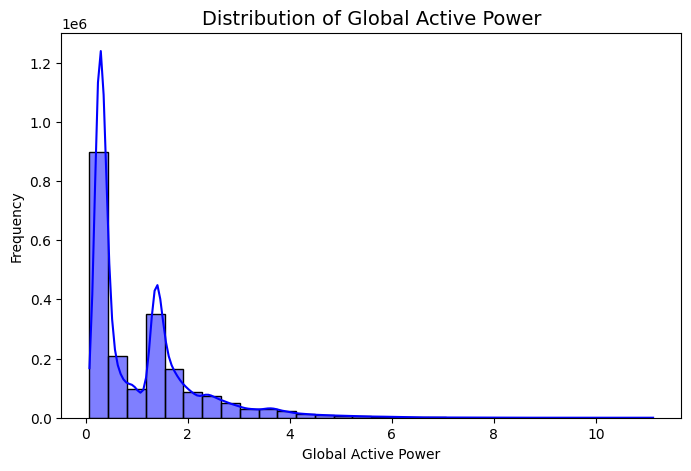

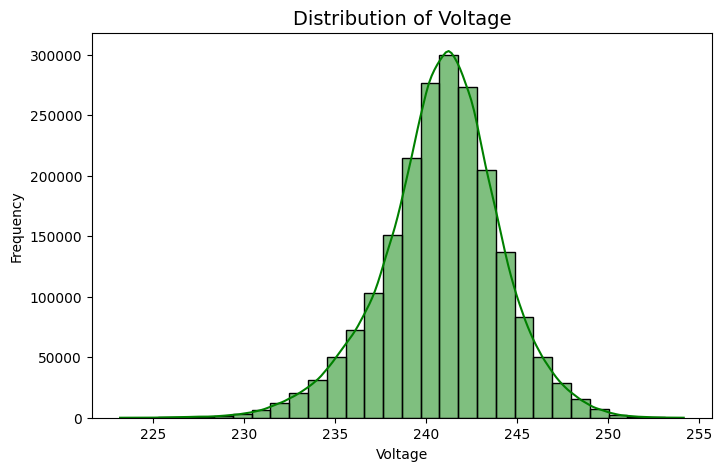

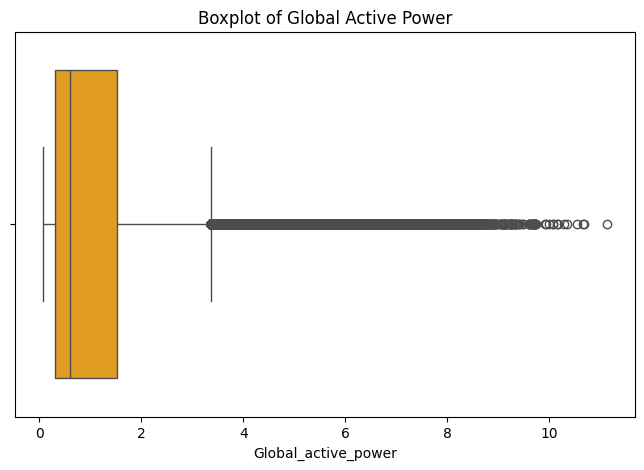

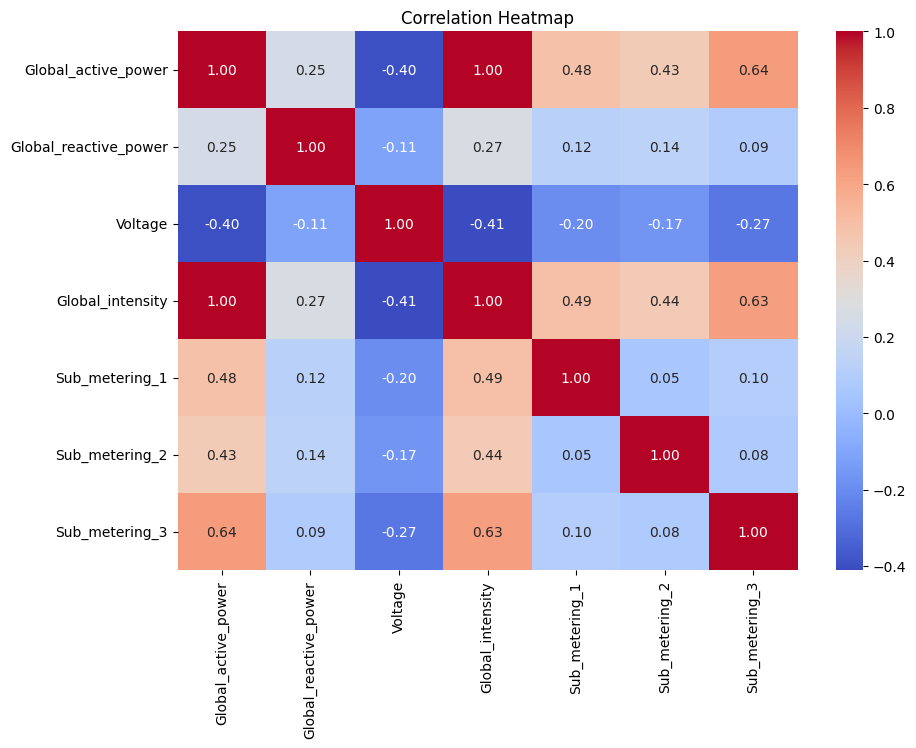


Shape After Removing Outliers:

(1913075, 9)

Scaled Data Sample:

   Global_active_power  Global_reactive_power   Voltage  Global_intensity  \
0             3.970872               3.058162 -1.916200          4.178144   
1             3.121430               1.660654 -1.291810          3.140969   
2             2.976898               0.362968 -1.426546          3.018948   
3             3.179750               0.402896 -1.318100          3.201979   
4             2.971826              -1.154327 -1.295096          3.018948   

   Sub_metering_1  Sub_metering_2  Sub_metering_3  
0       -0.125238        0.538787        1.303517  
1       -0.125238       -0.392957        1.303517  
2       -0.125238       -0.392957        1.303517  
3       -0.125238       -0.392957        1.303517  
4       -0.125238       -0.392957        1.423522  


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from scipy.stats import zscore
from sklearn.compose import ColumnTransformer

# LOAD DATASET


# Read dataset and treat '?' as missing values
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values=['?']
)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()


# BASIC DATA EXPLORATION

# Displaying first 10 rows
print("\nFirst 10 Rows:\n")
print(df.head(10))

# Shape of dataset
print("\nDataset Shape:\n")
print(df.shape)

# Dataset information
print("\nDataset Info:\n")
print(df.info())



# =========================================================
# CONVERT NUMERIC COLUMNS
# =========================================================

numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Convert columns to numeric datatype
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

print("\nNumerical Statistics:\n")
print(df.describe())

# =========================================================
# CHECK MISSING VALUES
# =========================================================

print("\nMissing Values:\n")
print(df.isnull().sum())

# =========================================================
# CHECK DATA TYPES
# =========================================================

print("\nData Types:\n")
print(df.dtypes)

# =========================================================
# VISUALIZATION 1:
# DISTRIBUTION OF GLOBAL ACTIVE POWER
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    x=df['Global_active_power'].dropna(),
    bins=30,
    kde=True,
    color='blue'
)

plt.title("Distribution of Global Active Power", fontsize=14)
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# VISUALIZATION 2:
# VOLTAGE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    x=df['Voltage'].dropna(),
    bins=30,
    kde=True,
    color='green'
)

plt.title("Distribution of Voltage", fontsize=14)
plt.xlabel("Voltage")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# VISUALIZATION 3:
# BOXPLOT FOR OUTLIERS
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Global_active_power'],
    color='orange'
)

plt.title("Boxplot of Global Active Power")

plt.show()

# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(10,7))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# OPTIONAL: REMOVE OUTLIERS USING Z-SCORE
# =========================================================

z_scores = np.abs(zscore(df[numeric_cols], nan_policy='omit'))

df_no_outliers = df[(z_scores < 3).all(axis=1)]

print("\nShape After Removing Outliers:\n")
print(df_no_outliers.shape)

# =========================================================
# OPTIONAL: FEATURE SCALING
# =========================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_no_outliers[numeric_cols].dropna())

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_cols
)

print("\nScaled Data Sample:\n")
print(scaled_df.head())

# =========================================================
# END OF CODE
# =========================================================


# Numerical Featres of Distribution 

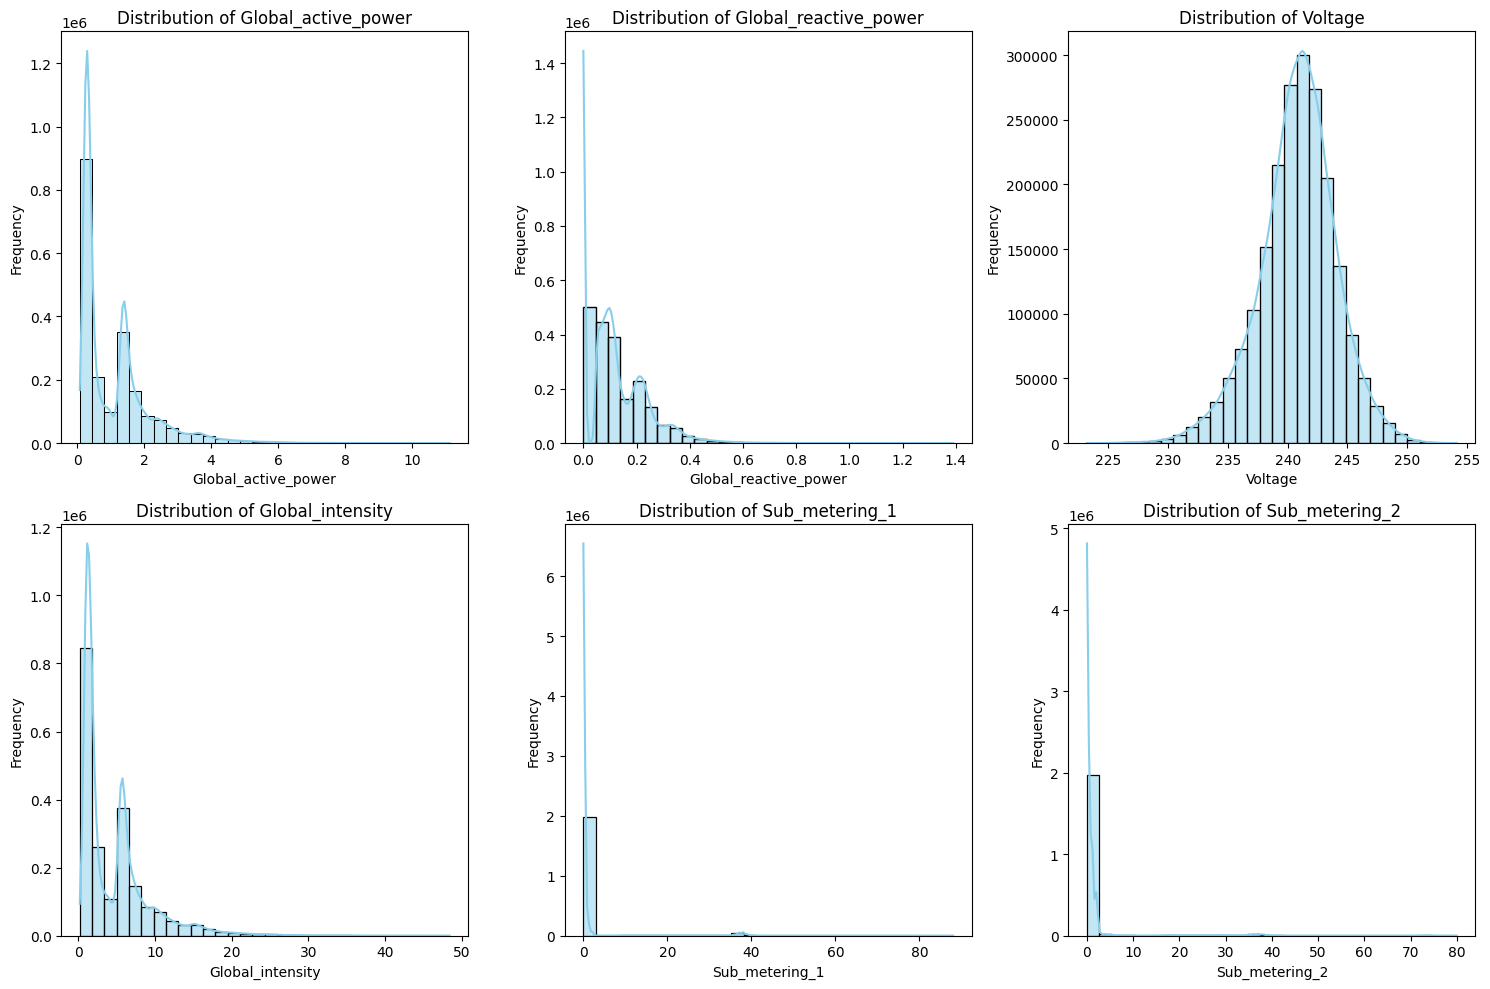

In [9]:
#  List of numberical features to plot (excluding target variable "EnergyConsumption")

numerical_features = ['Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2']


#  Creating subplots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
  plt.subplot(2,3,i)
  sns.histplot(data=df, x=feature, kde=True, bins=30, color="skyblue")
  plt.title(f"Distribution of {feature}")
  plt.xlabel(feature)
  plt.ylabel("Frequency")

  plt.tight_layout()

## Categorical feature distribution

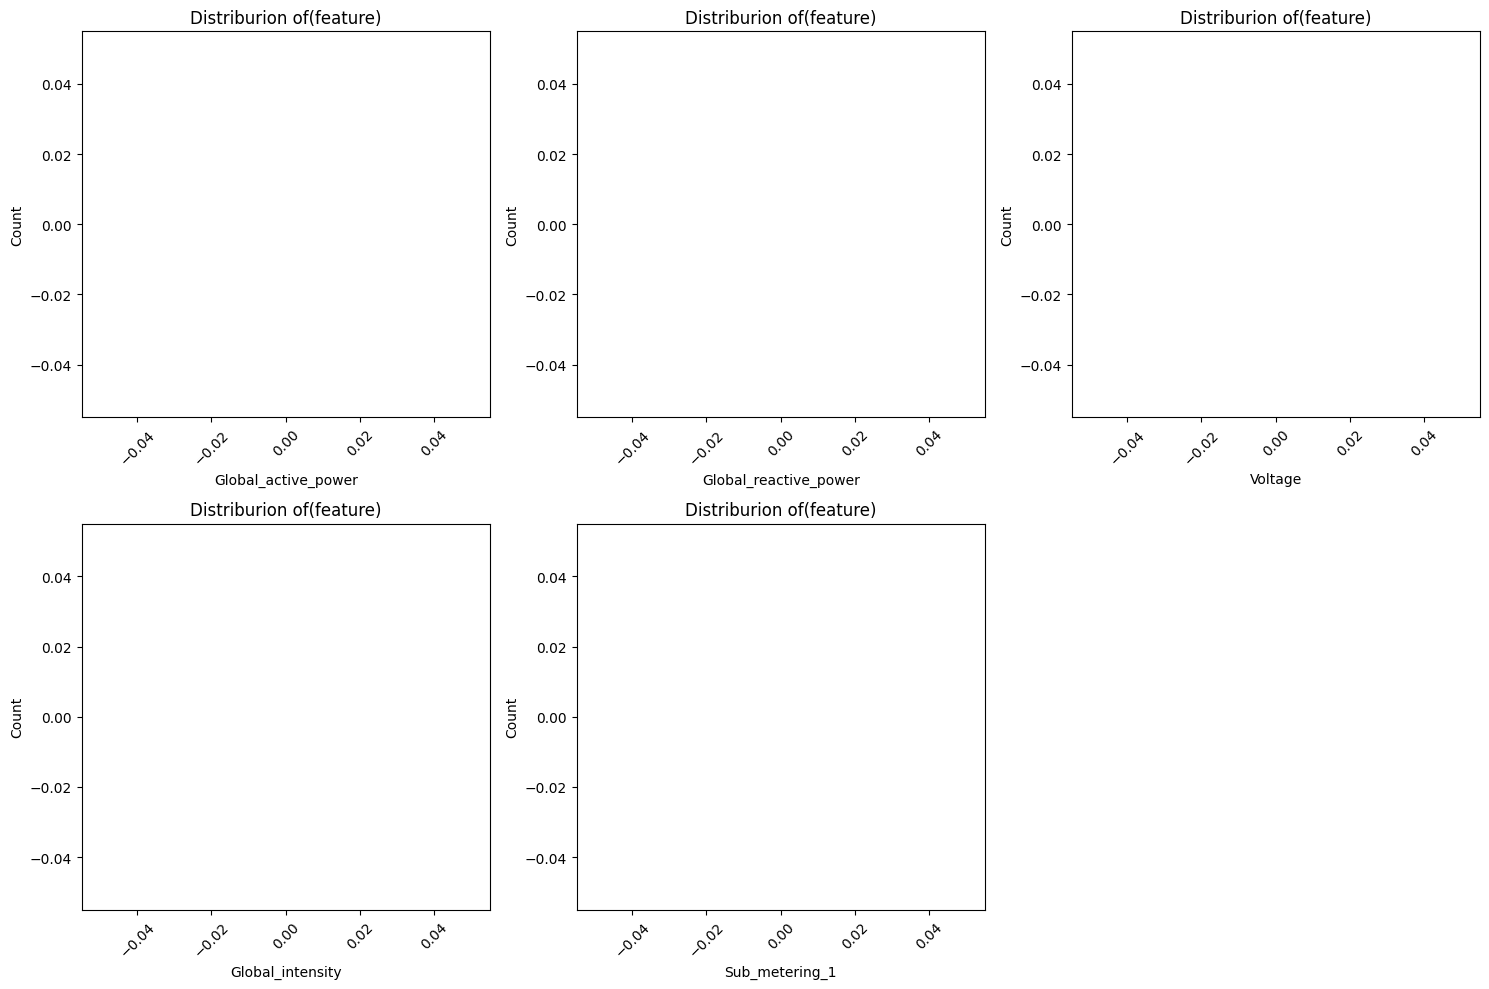

In [10]:
#  List of categorical features 
categorical_features = ['Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',]

#  Creating subplots
plt.figure(figsize=(15,10))
for i , feature in enumerate(categorical_features, 1):
  plt.subplot(2,3,i)
  # sns.countplot(data=df , hue=feature , legend=False, palette="coolwarm") # Assign hue and disable legenfd
  sns.histplot()
  plt.title(f"Distriburion of(feature)")
  plt.xlabel(feature)
  plt.ylabel("Count")
  plt.xticks(rotation = 45)  # Rotate x-axis labels for better readability if needed

plt.tight_layout()
plt.show()


### Bivariate Analysis 
- it is using scatter plot

Shape: (2049280, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 156.3+ MB
None

Describe:
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02  

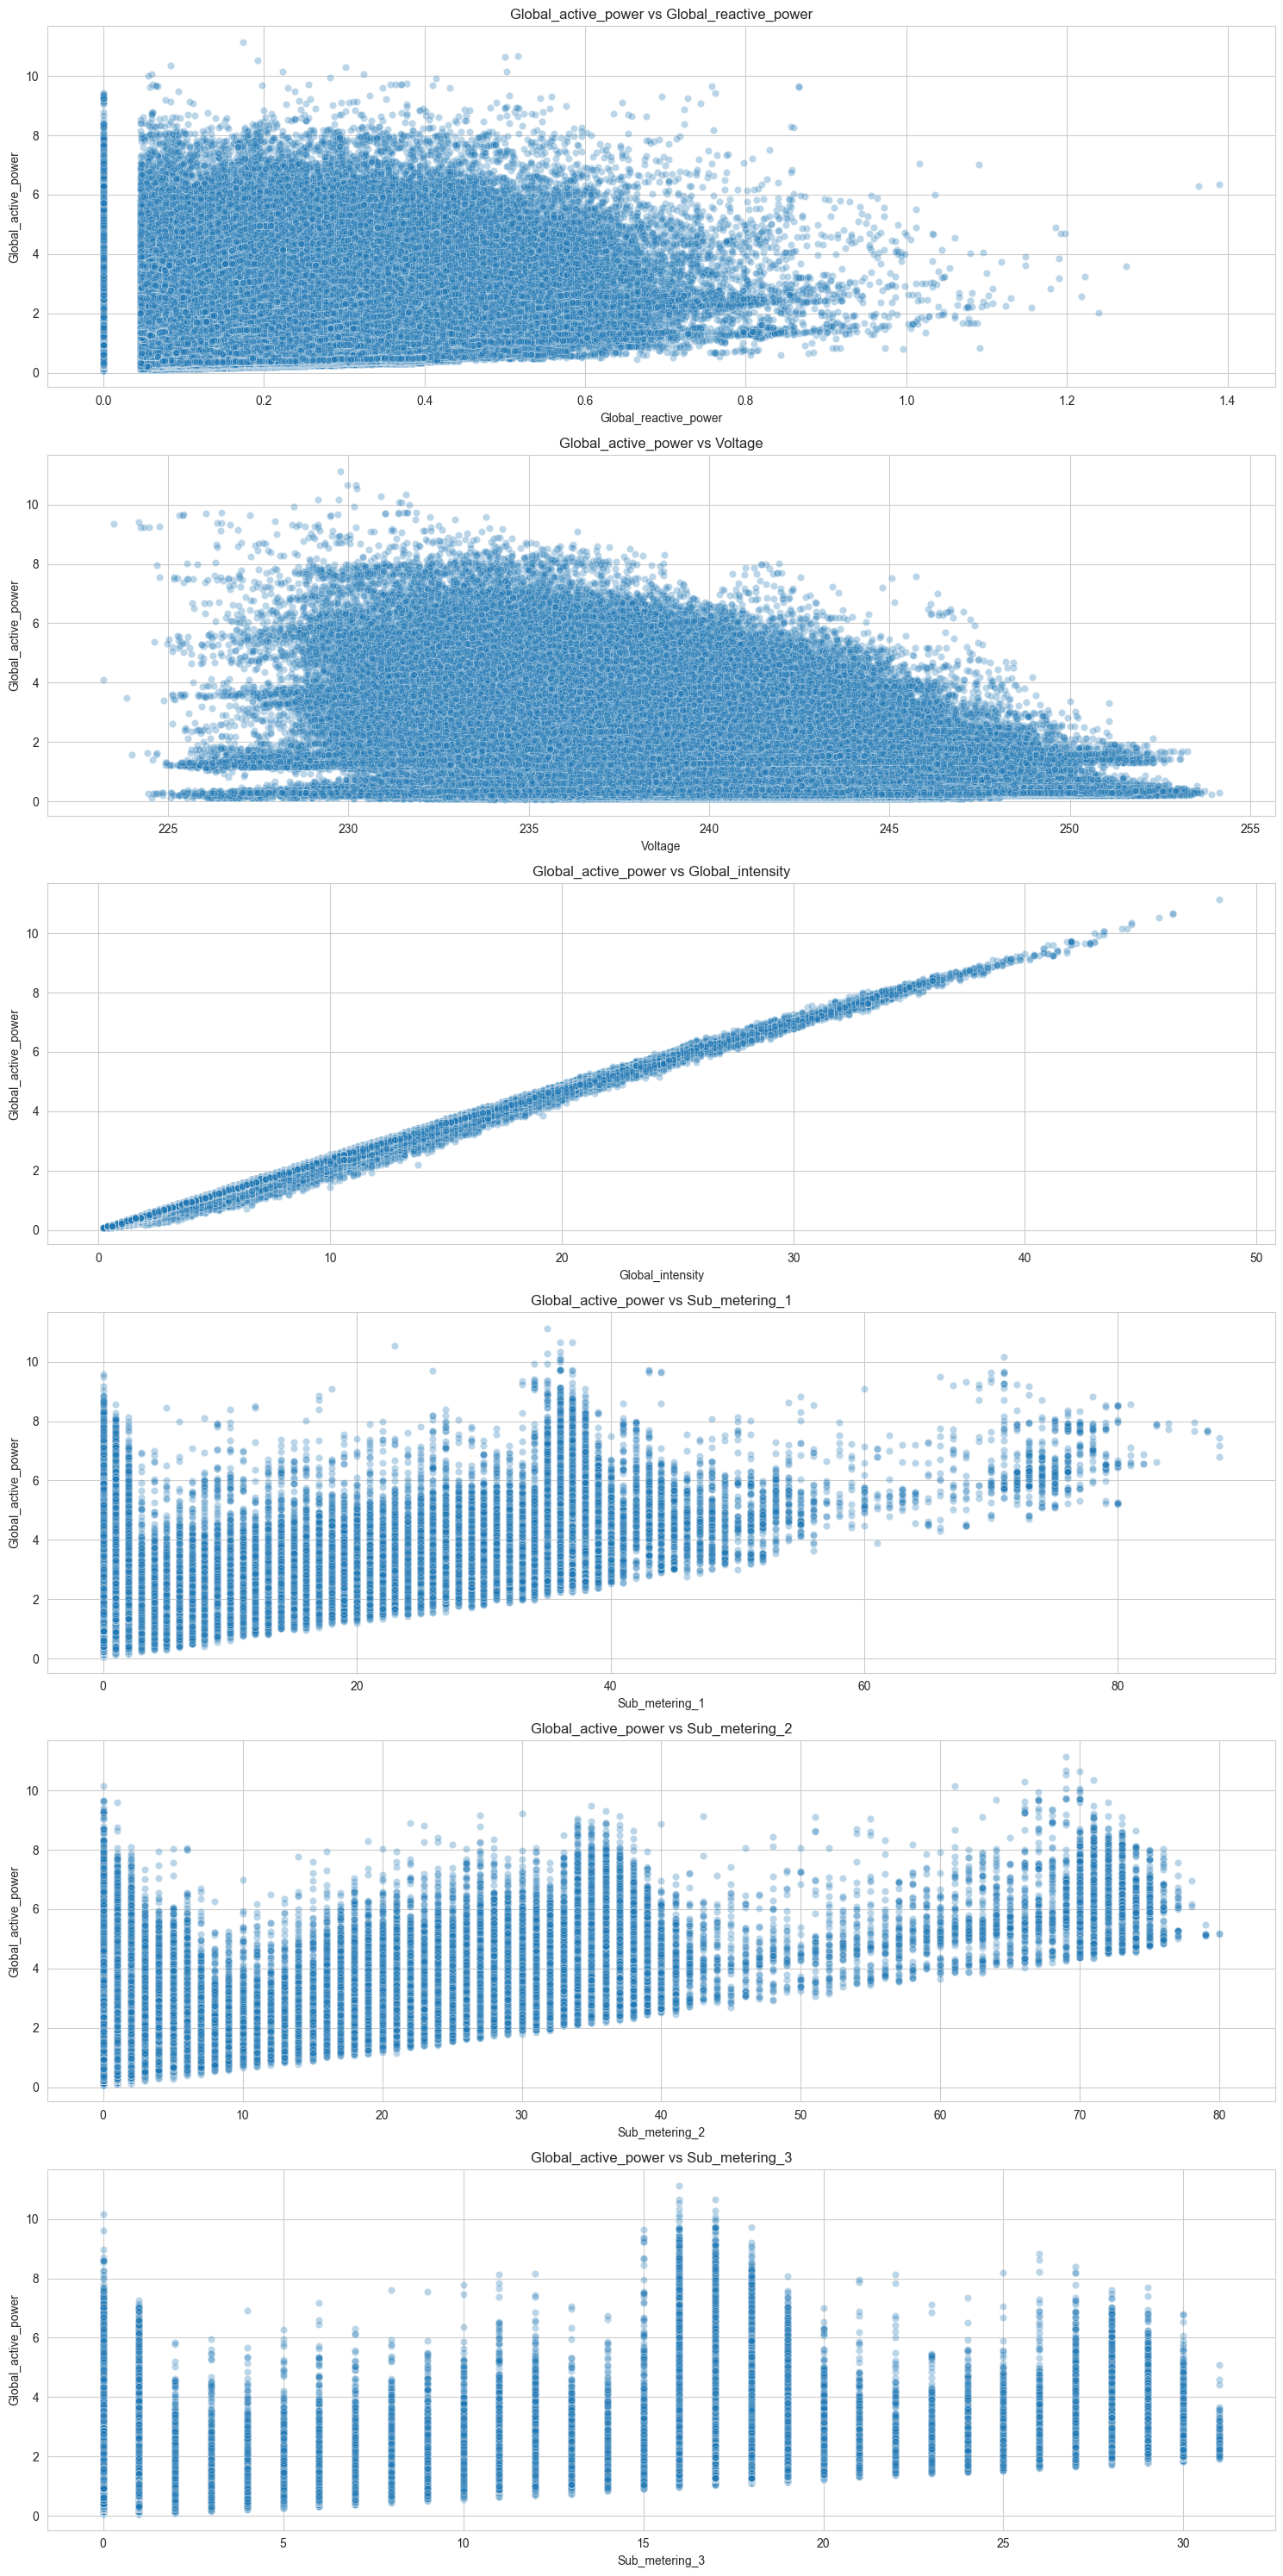

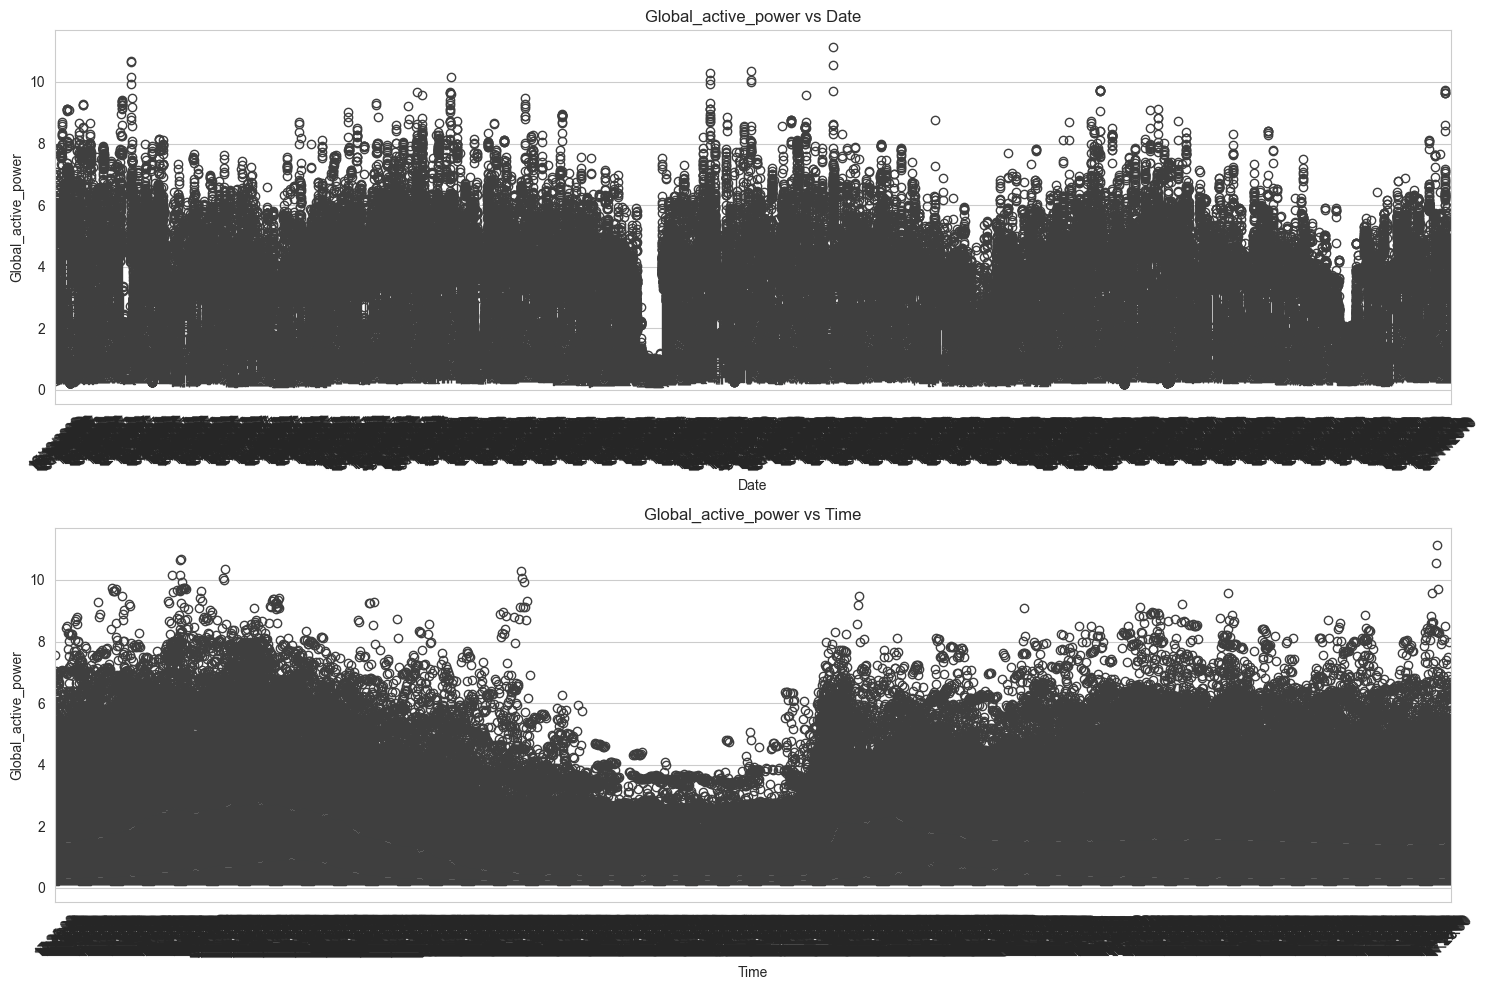

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# LOAD DATASET
# ======================================================

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values=['?']
)

# Clean column names
df.columns = df.columns.str.strip()

# ======================================================
# CONVERT NUMERIC COLUMNS
# ======================================================

numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values (important for clean plots)
df = df.dropna()

# ======================================================
# BASIC INFO
# ======================================================

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe:")
print(df.describe())

# ======================================================
# TARGET VARIABLE
# ======================================================

target_variable = "Global_active_power"

# ======================================================
# FEATURE SELECTION
# ======================================================

numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target safely
if target_variable in numerical_features:
    numerical_features.remove(target_variable)

# ======================================================
# PLOT 1: NUMERICAL FEATURES vs TARGET
# ======================================================

sns.set_style("whitegrid")

plt.figure(figsize=(15, 5 * len(numerical_features)))

for i, feature in enumerate(numerical_features, 1):

    plt.subplot(len(numerical_features), 1, i)

    sns.scatterplot(
        x=df[feature],
        y=df[target_variable],
        alpha=0.3
    )

    plt.title(f"{target_variable} vs {feature}")
    plt.xlabel(feature)
    plt.ylabel(target_variable)

plt.tight_layout()
plt.show()

# PLOT 2: CATEGORICAL FEATURES vs TARGET (if any)


if len(categorical_features) > 0:

    plt.figure(figsize=(15, 5 * len(categorical_features)))

    for i, feature in enumerate(categorical_features, 1):

        plt.subplot(len(categorical_features), 1, i)

        sns.boxplot(
            x=df[feature],
            y=df[target_variable]
        )

        plt.title(f"{target_variable} vs {feature}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [12]:
print (df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


## Correlation heatmap 

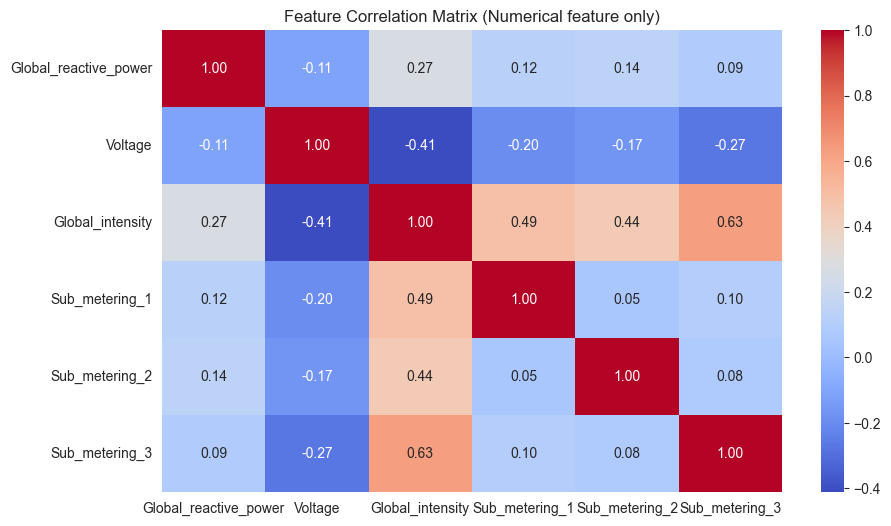

In [13]:
#  Plot the correlation heatmap
data_corr = df[numerical_features].corr()
plt.figure(figsize=(10,6))
sns.heatmap(data_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix (Numerical feature only)")
plt.show()